[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


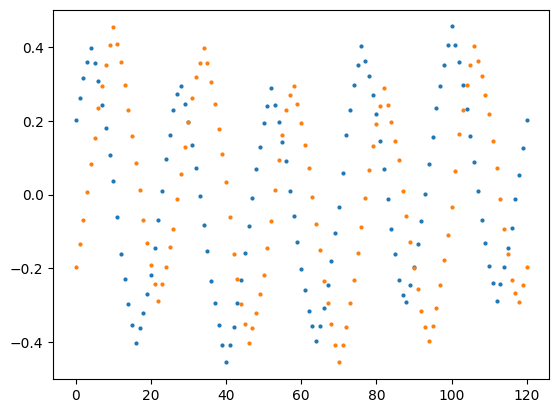

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti
from utils import get_sofa
from PIL import Image

ti.init(arch=ti.gpu)

path, file_name = '../trajectory/能让四分支旋转一周的房间_1/', 'sofa_600.npy'

# 载入轨迹数据
xs, ys, rotations = np.load(path + file_name)

# 数据点
plt.plot(xs, 'o', markersize=2)
plt.plot(ys, 'o', markersize=2)
# plt.plot(rotations, 'o', markersize=2)

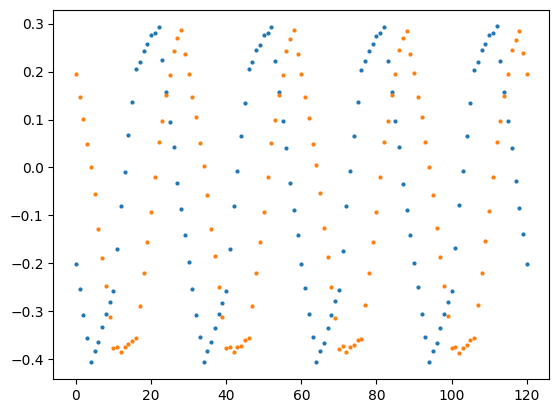

In [2]:
xs_inv_1 = []
ys_inv_1 = []
rotations_inv_1 = -rotations
for x, y, angle in zip(-xs, -ys, rotations_inv_1):
    rotation_matrix = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])
    x_inv, y_inv = rotation_matrix @ np.array([x, y])
    xs_inv_1.append(x_inv)
    ys_inv_1.append(y_inv)
xs_inv_1 = np.array(xs_inv_1)
ys_inv_1 = np.array(ys_inv_1)

plt.plot(xs_inv_1, 'o', markersize=2)
plt.plot(ys_inv_1, 'o', markersize=2)

In [3]:
def key_function(xs, ys, rotations):  # 要求这个函数单调递增来重新采样
    return np.arange(len(xs))  # 不重新排序

Area = 2.0645170000000004


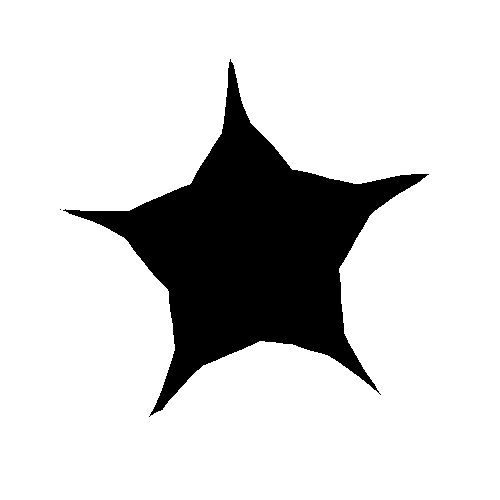

In [6]:
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    i1 = int(ti.math.atan2(y1, x1) / (ti.math.pi * 2) * 4 % 4)
    i2 = int(ti.math.atan2(y2, x2) / (ti.math.pi * 2) * 4 % 4)
    return i1 != i2 and ti.Vector([x2, y2]).norm() < 1

sofa_w, sofa_h = 3.5, 3.5   # 求解域的尺寸

def centralize(xs, ys, rotations):  # 中心化
    # print(np.mean(xs[:-1]), np.mean(ys[:-1]))
    xs -= np.mean(xs[:-1])  # 因为终点和起点重合，所以算中心时舍去最后一个点
    ys -= np.mean(ys[:-1])
    return xs, ys, rotations

sofa = get_sofa(
    is_forbidden,
    xs, ys, rotations,
    resolution=500,
    sofa_w=sofa_w, sofa_h=sofa_h,
    center_x=np.mean(xs_inv_1), center_y=np.mean(ys_inv_1),
    trajectory_upsampling=101
)
print(f'Area = {(1 - np.sum(sofa) / (sofa.shape[0] * sofa.shape[1])) * (sofa_w * sofa_h)}')

image = Image.fromarray(np.array(sofa.T[::-1] * 255, dtype=np.uint8))
image

array([  0,   1,   3,   8,  17,  35,  72, 146, 296, 600])

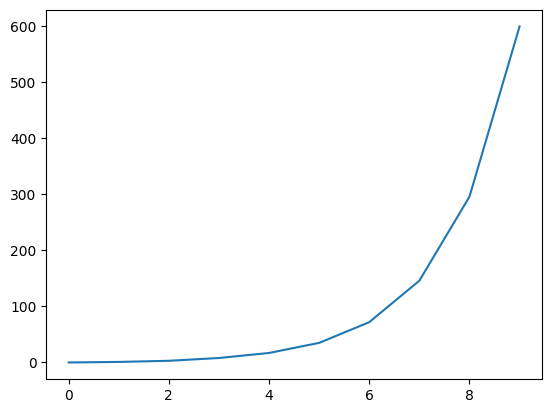

In [7]:
from animation_tools import generate_ids

cycles = 10
ids = generate_ids(0, 35, 600, cycles)  # 选取将在视频中展示的关键的代。因为初始进化快最终进化慢，后面间隔逐渐扩大
plt.plot(ids)
ids

In [8]:
# 渲染多个不同形状的房间里相同形状沙发的运动

from tqdm.notebook import tqdm
import os
from scipy.ndimage import zoom
from utils import test_forbidden_function
from animation_tools import draw_sofa, dilate, draw_pattern
from PIL import Image, ImageDraw, ImageFont
import aggdraw  # 用于抗锯齿绘图

resolution = (2560, 1440)
delta_x = -450  # 画面整体横向移动
origin = [None, resolution[1] // 2]  # 原点在屏幕中的位置，随着动画会改变
scale = 300  # 单位1对应多少像素
duration = 114  # 每个房间展示的时长
transition_duration = 21  # 切换房间（转场）用时
period = 86  # 沙发旋转一周用时
trajectory_display_upsampling = 5  # 轨迹显示时的上采样倍数
time_scale = 1.0
emit_every_frames = int((duration + transition_duration) * time_scale)

output_path = '../rendering_results/能让四分支旋转一周的房间/'
save_no_trajectory_image_in_last_frames = 100  # 在最后若干帧里保存没有轨迹的版本（这是为了制作封面）

background_boundary_thickness = 12
background_upsampling = 3
sofa_upsampling = 2
need_update_background = True

# 如果输出路径不存在，构建路径
if not os.path.exists(output_path):
    os.makedirs(output_path)

r = 1.75
sofa_w, sofa_h = 2 * r, 2 * r
thisckness = 0.015
sofa_numpy = test_forbidden_function(  # 房间进化问题中移动的沙发实际上对应普通移动沙发问题中的墙壁（因为这里的沙发是给定形状的），而墙壁对应沙发（因为这里的墙壁的形状是待求的）
    is_forbidden,
    -r, r,
    -r, r,
    [int(scale * r * 2 * sofa_upsampling)] * 2,
    wall_normal=[0, thisckness]
)
sofa_numpy = np.logical_or(sofa_numpy, test_forbidden_function(  # 房间进化问题中移动的沙发实际上对应普通移动沙发问题中的墙壁（因为这里的沙发是给定形状的），而墙壁对应沙发（因为这里的墙壁的形状是待求的）
    is_forbidden,
    -r, r,
    -r, r,
    [int(scale * r * 2 * sofa_upsampling)] * 2,
    wall_normal=[thisckness, 0]
))

active_rooms = []

def add_new_room(frame):
    id = ids[frame // emit_every_frames]
    assert os.path.exists(f'{path}sofa_{id}.npy')

    image = np.ones(list(sofa_numpy.T.shape) + [4])
    draw_pattern(image, (id + 77) % 1000000)  # 绘制随机花纹，改变里面的常数就可以让花纹不一样
    image[:, :, 3] = sofa_numpy.T[::-1] * 255
    image = Image.fromarray(image.astype(np.uint8))
    xs, ys, rotations = np.load(f'{path}sofa_{id}.npy')

    # 采样
    xs_upsampled_1 = zoom(xs, zoom=(int(period * time_scale) + 1) / len(xs), order=1)[:-1]  # 插值到动画循环帧数，用于将沙发绘制在正确的位置
    ys_upsampled_1 = zoom(ys, zoom=(int(period * time_scale) + 1) / len(ys), order=1)[:-1]
    rotations_upsampled_1 = zoom(rotations, zoom=(int(period * time_scale) + 1) / len(rotations), order=1)[:-1]
    xs_upsampled_2 = zoom(xs, zoom=(int(period * time_scale * trajectory_display_upsampling) + 1) / len(xs), order=1)[:-1]  # 用于绘制轨迹
    ys_upsampled_2 = zoom(ys, zoom=(int(period * time_scale * trajectory_display_upsampling) + 1) / len(ys), order=1)[:-1]
    rotations_upsampled_2 = zoom(rotations, zoom=(int(period * time_scale * trajectory_display_upsampling) + 1) / len(rotations), order=1)[:-1]

    # 求逆
    xs_inv_1 = []
    ys_inv_1 = []
    rotations_inv_1 = -rotations_upsampled_1
    for x, y, angle in zip(-xs_upsampled_1, -ys_upsampled_1, rotations_inv_1):
        rotation_matrix = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])
        x_inv, y_inv = rotation_matrix @ np.array([x, y])
        xs_inv_1.append(x_inv)
        ys_inv_1.append(y_inv)
    xs_inv_1 = np.array(xs_inv_1)
    ys_inv_1 = np.array(ys_inv_1)
    xs_inv_2 = []
    ys_inv_2 = []
    rotations_inv_2 = -rotations_upsampled_2
    for x, y, angle in zip(-xs_upsampled_2, -ys_upsampled_2, rotations_inv_2):
        rotation_matrix = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])
        x_inv, y_inv = rotation_matrix @ np.array([x, y])
        xs_inv_2.append(x_inv)
        ys_inv_2.append(y_inv)
    xs_inv_2 = np.array(xs_inv_2)
    ys_inv_2 = np.array(ys_inv_2)

    # 背景
    background = get_sofa(
        is_forbidden,
        xs, ys, rotations,
        resolution=resolution[0] * background_upsampling,
        sofa_w=resolution[0] / scale, sofa_h=resolution[1] / scale,
        center_x=np.mean(xs_inv_1),
        center_y=np.mean(ys_inv_1),
        trajectory_upsampling=401
    )
    ti.reset()  # 释放显存
    ti.init(arch=ti.gpu)
    area = np.sum(~background) / (scale * background_upsampling) ** 2
    background = background.T[::-1]
    y = (background.shape[0] - np.argmin(np.all(background, axis=1)[::-1])) / background_upsampling  # 房间最下端位置
    background_dilate = 1 - dilate(1 - background, radius=background_boundary_thickness * background_upsampling)
    background = np.array((255 - background * 75) * (1 - np.logical_xor(background, background_dilate)), dtype=np.uint8)
    background = np.stack([background, background, background], axis=-1)
    background = Image.fromarray(background)
    background = background.resize((background.width // background_upsampling, background.height // background_upsampling))
    draw = ImageDraw.Draw(background)
    text = f"#{id * 100}   S = {area:.4f}"
    font = ImageFont.truetype("simhei.ttf", 75)
    text_length = draw.textlength(text, font=font)
    draw.text((resolution[0] // 2 - text_length // 2, min(y + 50, resolution[1] - 100)), text, fill=(0, 0, 0), font=font)

    shift_x = frame // emit_every_frames * resolution[0] / scale - np.mean(xs_inv_1)
    shift_y = -np.mean(ys_inv_1)
    xs_inv_1 += shift_x
    ys_inv_1 += shift_y
    xs_inv_2 += shift_x
    ys_inv_2 += shift_y

    active_rooms.append({
        'cycle': frame // emit_every_frames,
        'start_frame': frame,
        'sofa': image,  # 虽然每个房间的沙发形状相同，但为了好看绘制不同花纹，所以每个有独立的图片
        'background': background,
        # 'xs': xs,
        # 'ys': ys,
        # 'rotations': rotations,
        'xs_inv_1': xs_inv_1,
        'ys_inv_1': ys_inv_1,
        'rotations_inv_1': rotations_inv_1,
        'xs_inv_2': xs_inv_2,
        'ys_inv_2': ys_inv_2,
        'rotations_inv_2': rotations_inv_2
    })

add_new_room(0)
frames = emit_every_frames * cycles + 100
for frame in tqdm(range(frames)):
    cycle = frame // emit_every_frames
    frame_in_cycle = frame % emit_every_frames
    if frame_in_cycle == 0 or frame_in_cycle > duration * time_scale:
        if frame_in_cycle == 0:  # 刚转场完毕
            if cycle < cycles:
                origin[0] = resolution[0] * (0.5 - cycle) + delta_x
                while active_rooms[0]['cycle'] < cycle:
                    del active_rooms[0]  # 移除已经离开画面的房间
                need_update_background = True
        else:  # 正在转场
            if cycle < cycles - 1:
                if active_rooms[-1]['cycle'] <= cycle:  # 需要加入新的沙发
                    add_new_room((cycle + 1) * emit_every_frames)
                origin[0] = resolution[0] * (0.5 - cycle - (1 - np.cos((frame_in_cycle - duration * time_scale) / (transition_duration * time_scale) * np.pi)) / 2) + delta_x  # 转场
                need_update_background = True  # 转场时每帧都要重新渲染背景

    # 绘制背景
    rendering_target = Image.new('RGB', resolution, (180, 180, 180))
    for room in active_rooms:
        rendering_target.paste(room['background'], (round(resolution[0] * (-0.5 + room['cycle']) + origin[0]), 0))  # 将背景绘制到画布中

    # 绘制沙发
    for room in active_rooms:
        draw_sofa(
            rendering_target,
            origin, scale,
            room['sofa'],
            room['xs_inv_1'], room['ys_inv_1'], room['rotations_inv_1'],
            (frame - room['start_frame']) % int(period * time_scale),
            sofa_h=sofa_h,
        )

    if frame >= frames - save_no_trajectory_image_in_last_frames:
         rendering_target.save(f"{output_path}{frame}_no_trajectory.png", compress_level=6)  # 保存没有轨迹的版本

    # 绘制轨迹
    draw = aggdraw.Draw(rendering_target)  # 消除锯齿绘图对象
    pen = aggdraw.Pen('black', 2, opacity=255)
    for room in active_rooms:
        for i in range(1, min(len(room['xs_inv_2']), (frame - room['start_frame']) * trajectory_display_upsampling) + 1):
           draw.line(
               (
                   origin[0] + room['xs_inv_2'][i % len(room['xs_inv_2'])] * scale,
                   origin[1] - room['ys_inv_2'][i % len(room['ys_inv_2'])] * scale,
                   origin[0] + room['xs_inv_2'][i - 1] * scale,
                   origin[1] - room['ys_inv_2'][i - 1] * scale
                ),
               pen
           )
    draw.flush()

    rendering_target.save(f"{output_path}{frame}.png", compress_level=6)

    # if frame > 170:
    #     break
    # break
# rendering_target

[Taichi] Starting on arch=cuda


  0%|          | 0/1450 [00:00<?, ?it/s]

[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
[Taichi] Starting on arch=cuda
